In [1]:
import sys
sys.path.append('../')
from utils_models import *


(<Figure size 640x480 with 2 Axes>, <Axes: >)

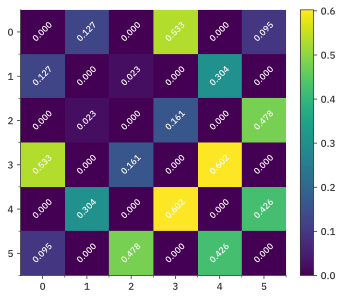

In [3]:
EJ = 2.7
EC = 0.6
EL = 0.13


qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=6)
qbt.plot_matrixelements('n_operator',evals_count=6,show_numbers=True,show3d=0)

In [57]:
dim = 10
qbt_1 = scqubits.Fluxonium(3,
                        EC = 0.6,
                        EL = 0.13,
                        flux=0,cutoff=110,truncated_dim=dim)

qbt_2 = scqubits.Fluxonium(EJ = 4,
                        EC = 0.9,
                        EL = 0.2,
                        flux=0,cutoff=110,truncated_dim=dim)


# matrix1 = qbt_1.matrixelement_table('n_operator',evals_count=dim)

evals_a = qbt_1.eigenvals(evals_count=dim)
evals_b = qbt_2.eigenvals(evals_count=dim)

# def transmission_rate(w_b,state_a):
#     rate = 0
#     for i in range(len(matrix1)):
#         sign = 1
#         if i<state_a :
#             sign = -1
#         rate +=  sign * abs(matrix1[i,state_a]**2)/(abs(evals_a[state_a]-evals_a[i]) - w_b)
#     return rate

# print(f"q1 freq {evals_a[3]-evals_a[2]}, q2 freq {evals_b[1]-evals_b[0]}")
# print(f"transmission rate for qubit in state 2 {transmission_rate(evals_b[1] - evals_b[0], 1)}")  
# print(f"transmission rate for qubit in state 2 {transmission_rate(evals_b[1] - evals_b[0], 2)}")  

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

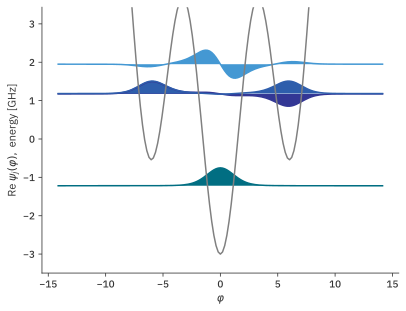

In [58]:
qbt_1.plot_wavefunction(which = [0,1,2,3])

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

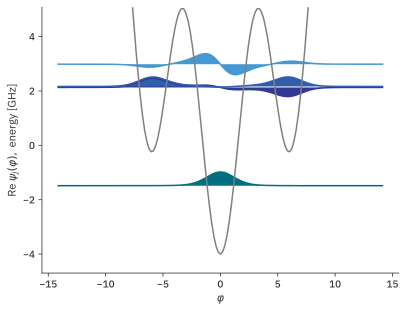

In [59]:
qbt_2.plot_wavefunction(which = [0,1,2,3])

In [60]:
hilbertspace = scqubits.HilbertSpace([qbt_1, qbt_2])
hilbertspace.add_interaction(
    g_strength=0.35,
    op1=qbt_1.n_operator,
    op2=qbt_2.n_operator,
)
hilbertspace.generate_lookup()

def transition_frequency(s0: int, s1: int) -> float:
    return (
        (
            hilbertspace.energy_by_dressed_index(s1)
            - hilbertspace.energy_by_dressed_index(s0)
        )
        * 2
        * np.pi
    )

n_a = hilbertspace.op_in_dressed_eigenbasis(qbt_1.n_operator)
n_b = hilbertspace.op_in_dressed_eigenbasis(qbt_2.n_operator)


In [62]:
def print_cross_and_direct_matrix_elements(n_a,n_b,
                                           ca0,ca1,
                                           cb0,cb1):
    print(f"q1 freq {evals_a[ca1]-evals_a[ca0]}, q2 freq {evals_b[cb1]-evals_b[cb0]}")
    print("cross")
    print(n_a[hilbertspace.dressed_index((ca0, cb0)),hilbertspace.dressed_index((ca0, cb1))])
    print(n_a[hilbertspace.dressed_index((ca1, cb0)),hilbertspace.dressed_index((ca1, cb1))])
    print(n_b[hilbertspace.dressed_index((ca0, cb0)),hilbertspace.dressed_index((ca1, cb0))])
    print(n_b[hilbertspace.dressed_index((ca0, cb1)),hilbertspace.dressed_index((ca1, cb1))])
    print("direct")
    print(n_b[hilbertspace.dressed_index((ca0, cb0)),hilbertspace.dressed_index((ca0, cb1))])
    print(n_b[hilbertspace.dressed_index((ca1, cb0)),hilbertspace.dressed_index((ca1, cb1))])
    print(n_a[hilbertspace.dressed_index((ca0, cb0)),hilbertspace.dressed_index((ca1, cb0))])
    print(n_a[hilbertspace.dressed_index((ca0, cb1)),hilbertspace.dressed_index((ca1, cb1))])

print_cross_and_direct_matrix_elements(n_a,n_b,
                                        0,1,
                                        1,2)

q1 freq 2.393587055038121, q2 freq 0.035800252774571106
cross
-0.0019220488749318997j
-0.0018134392482929511j
-0.0040756150892831975j
-0.004848200346851843j
direct
0.02637340399099787j
0.028946315854462456j
0.0854035738281894j
0.08662165079785823j


In [24]:

product_states = [ (1, 1), (1,2), (2, 1), (2, 2)]
idxs = [hilbertspace.dressed_index((s1, s2)) for (s1, s2) in product_states]
states = [qutip.basis(hilbertspace.dimension, idx) for idx in idxs]

omega_d = transition_frequency( hilbertspace.dressed_index((1, 2)) , hilbertspace.dressed_index((2, 2)))

A = 0.001
B = 1*A *20
def drive_coeff(t: float, args: dict) -> float:
    return A * np.cos(omega_d * t)

def drive_coeff_2(t: float, args: dict) -> float:
    return B * np.cos(omega_d * t)

(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = 2 * np.pi * qutip.Qobj(np.diag(evals))

H_qbt_drive = [
    diag_dressed_hamiltonian,
    [2 * np.pi * n_a, drive_coeff],  # driving through the resonator
    [2 * np.pi * n_b, drive_coeff_2],  # driving through the resonator
]

tlist = np.linspace(0, 200, 200)  # total time


 Total run time:   4.01s*] Elapsed 4.01s / Remaining 00:00:00:00


Text(0.5, 0, 't (ns)')

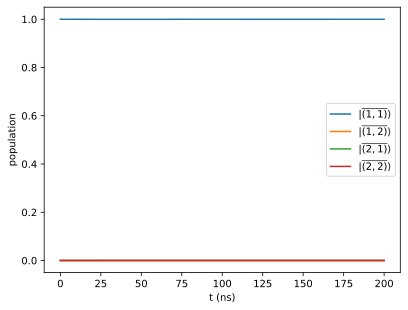

In [26]:
result = qutip.sesolve(
    H_qbt_drive,
    qutip.basis(hilbertspace.dimension, hilbertspace.dressed_index((1,1))),
    tlist,
    e_ops=[state * state.dag() for state in states],
    progress_bar = qutip.ui.progressbar.EnhancedTextProgressBar()
)

for i, res in enumerate( result.expect):
    plt.plot(tlist, res, label=rf"$| \overline{{{product_states[i]}}} \rangle$")

plt.legend()
plt.ylabel("population")
plt.xlabel("t (ns)")



 Total run time:   4.01s*] Elapsed 4.01s / Remaining 00:00:00:00


Text(0.5, 0, 't (ns)')

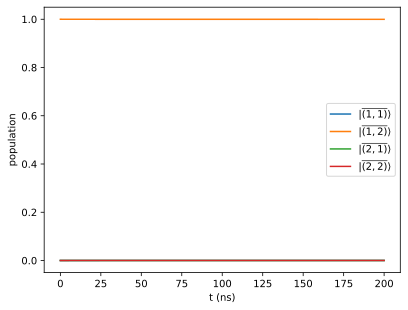

In [25]:

result = qutip.sesolve(
    H_qbt_drive,
    qutip.basis(hilbertspace.dimension, hilbertspace.dressed_index((1,2))),
    tlist,
    e_ops=[state * state.dag() for state in states],
    progress_bar = qutip.ui.progressbar.EnhancedTextProgressBar()
)

for i, res in enumerate( result.expect):
    plt.plot(tlist, res, label=rf"$| \overline{{{product_states[i]}}} \rangle$")

plt.legend()
plt.ylabel("population")
plt.xlabel("t (ns)")



In [136]:
dim = 10
qbt_1 = scqubits.Fluxonium(EJ = 4.03,
                        EC = 1.18,
                        EL = 0.78,
                        flux=0,cutoff=110,truncated_dim=dim)

qbt_2 = scqubits.Fluxonium(EJ = 4.34,
                        EC = 1.13,
                        EL = 1.42,
                        flux=0,cutoff=110,truncated_dim=dim)

matrix1 = qbt_1.matrixelement_table('n_operator',evals_count=dim)


evals_a = qbt_1.eigenvals(evals_count=dim)
evals_b = qbt_2.eigenvals(evals_count=dim)

hilbertspace = scqubits.HilbertSpace([qbt_1, qbt_2])
hilbertspace.add_interaction(
    g_strength=0.28,
    op1=qbt_1.n_operator,
    op2=qbt_2.n_operator,
)
hilbertspace.generate_lookup()

def transition_frequency(s0: int, s1: int) -> float:
    return (
        (
            hilbertspace.energy_by_dressed_index(s1)
            - hilbertspace.energy_by_dressed_index(s0)
        )
        * 2
        * np.pi
    )

n_a = hilbertspace.op_in_dressed_eigenbasis(qbt_1.n_operator)

n_b = hilbertspace.op_in_dressed_eigenbasis(qbt_2.n_operator)

product_states = [ (0, 0), (0,1), (1, 0), (1, 1)]
idxs = [hilbertspace.dressed_index((s1, s2)) for (s1, s2) in product_states]
states = [qutip.basis(hilbertspace.dimension, idx) for idx in idxs]

omega_1011 = transition_frequency( hilbertspace.dressed_index((1, 1)) , hilbertspace.dressed_index((1, 0)))


A = 0.05
B = -1* A * 0.1
def drive_coeff(t: float, args: dict) -> float:
    return A * np.cos(omega_1011 * t)

def drive_coeff_2(t: float, args: dict) -> float:
    return B * np.cos(omega_1011 * t)

(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = 2 * np.pi * qutip.Qobj(np.diag(evals))

H_qbt_drive = [
    diag_dressed_hamiltonian,
    [2 * np.pi * n_a, drive_coeff],  # driving through the resonator
    [2 * np.pi * n_b, drive_coeff_2],  # driving through the resonator
]


tlist = np.linspace(0, 40, 40)  # total time


 Total run time:   3.63s*] Elapsed 3.62s / Remaining 00:00:00:00


Text(0.5, 0, 't (ns)')

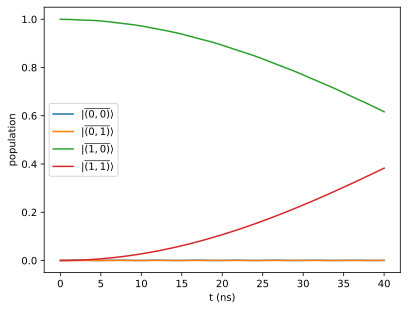

In [138]:


result = qutip.sesolve(
    H_qbt_drive,
    qutip.basis(hilbertspace.dimension, hilbertspace.dressed_index((1,0))),
    tlist,
    e_ops=[state * state.dag() for state in states],
    progress_bar = qutip.ui.progressbar.EnhancedTextProgressBar(),
    options= qutip.Options(nsteps=120000)
)

for i, res in enumerate( result.expect):
    plt.plot(tlist, res, label=rf"$| \overline{{{product_states[i]}}} \rangle$")

plt.legend()
plt.ylabel("population")
plt.xlabel("t (ns)")



 Total run time:   3.47s*] Elapsed 3.47s / Remaining 00:00:00:00


Text(0.5, 0, 't (ns)')

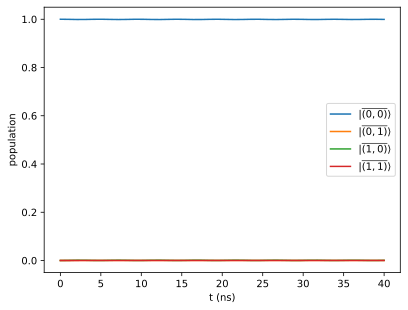

In [137]:


result = qutip.sesolve(
    H_qbt_drive,
    qutip.basis(hilbertspace.dimension, hilbertspace.dressed_index((0,0))),
    tlist,
    e_ops=[state * state.dag() for state in states],
    progress_bar = qutip.ui.progressbar.EnhancedTextProgressBar(),
    options= qutip.Options(nsteps=120000)
)

for i, res in enumerate( result.expect):
    plt.plot(tlist, res, label=rf"$| \overline{{{product_states[i]}}} \rangle$")

plt.legend()
plt.ylabel("population")
plt.xlabel("t (ns)")

